<a href="https://colab.research.google.com/github/rencyTarapara/Soil-Analysis-using-Machine-Learning/blob/main/Soil_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File path
file_path = '/content/drive/My Drive/Colab Notebooks/soildataset.xlsx'

# Correct function
df = pd.read_excel(file_path)

print("File loaded successfully!")
print(df.head())

Mounted at /content/drive
File loaded successfully!
      Records     410    435     460     485     510     535    560    585  \
0   100_0ml-1  720.93  146.4  366.36  102.16  174.56  175.43  29.18  35.59   
1   100_0ml-1  716.31  146.4  365.45   94.56  173.06  160.69  24.62  29.86   
2  100_0ml-10  719.39  146.4  366.36   96.25  174.56  162.10  27.36  33.13   
3  100_0ml-10  715.54  146.4  366.36   95.40  173.81  163.50  25.08  30.27   
4   100_0ml-2  720.93  146.4  366.36   95.40  174.56  163.50  27.36  33.13   

      610  ...    900   940  Capacitity Moist  Temp  Moist  EC (u/10 gram)  \
0  150.25  ...  13.83  7.08            2639.0  36.1    0.0             0.0   
1  141.01  ...  13.83  7.08            2650.0  38.2    0.0             0.0   
2  138.70  ...  14.40  7.08            2638.0  36.1    0.0             0.0   
3  144.47  ...  14.40  7.08            2636.0  38.2    0.0             0.0   
4  139.85  ...  13.83  7.08            2637.0  36.1    0.0             0.0   

     Ph  N

In [ ]:
import re

# Convert 'Records' column to string type to avoid TypeError
df['Records'] = df['Records'].astype(str)

# Extract the volume information (e.g., '0ml', '25ml', '50ml') into a temporary column
df['Volume_Extracted'] = df['Records'].apply(lambda x: re.search(r'(\d+ml)', x).group(1) if re.search(r'(\d+ml)', x) else None)

# Define the volumes to keep
volumes_to_keep = ['0ml', '25ml', '50ml']

# Filter the DataFrame, keeping the 'Volume_Extracted' column
df_filtered = df[df['Volume_Extracted'].isin(volumes_to_keep)].copy()

# The 'Volume_Extracted' column is now correctly in df_filtered and available for classification

print("DataFrame filtered successfully. Displaying the first 5 rows of the filtered DataFrame:")
print(df_filtered.head())
print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

DataFrame filtered successfully. Displaying the first 5 rows of the filtered DataFrame:
      Records     410    435     460     485     510     535    560    585  \
0   100_0ml-1  720.93  146.4  366.36  102.16  174.56  175.43  29.18  35.59   
1   100_0ml-1  716.31  146.4  365.45   94.56  173.06  160.69  24.62  29.86   
2  100_0ml-10  719.39  146.4  366.36   96.25  174.56  162.10  27.36  33.13   
3  100_0ml-10  715.54  146.4  366.36   95.40  173.81  163.50  25.08  30.27   
4   100_0ml-2  720.93  146.4  366.36   95.40  174.56  163.50  27.36  33.13   

      610  ...   940  Capacitity Moist  Temp  Moist  EC (u/10 gram)    Ph  \
0  150.25  ...  7.08            2639.0  36.1    0.0             0.0  7.88   
1  141.01  ...  7.08            2650.0  38.2    0.0             0.0  7.60   
2  138.70  ...  7.08            2638.0  36.1    0.0             0.0  8.02   
3  144.47  ...  7.08            2636.0  38.2    0.0             0.0  7.52   
4  139.85  ...  7.08            2637.0  36.1    0.0       

In [ ]:
print(f"Shape of df_filtered before dropping duplicates and columns: {df_filtered.shape}")

# Drop duplicate records
df_filtered.drop_duplicates(inplace=True)

# Drop specified columns
columns_to_drop = ['Records', 'Capacitity Moist', 'Temp']
# Check if columns exist before dropping
existing_columns_to_drop = [col for col in columns_to_drop if col in df_filtered.columns]

if existing_columns_to_drop:
    df_filtered.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("None of the specified columns to drop were found in the DataFrame.")

print(f"Shape of df_filtered after dropping duplicates and columns: {df_filtered.shape}")
print(df_filtered.head())

Shape of df_filtered before dropping duplicates and columns: (1570, 28)
Dropped columns: ['Records', 'Capacitity Moist', 'Temp']
Shape of df_filtered after dropping duplicates and columns: (1570, 25)
      410    435     460     485     510     535    560    585     610    645  \
0  720.93  146.4  366.36  102.16  174.56  175.43  29.18  35.59  150.25  46.71   
1  716.31  146.4  365.45   94.56  173.06  160.69  24.62  29.86  141.01  42.94   
2  719.39  146.4  366.36   96.25  174.56  162.10  27.36  33.13  138.70  46.71   
3  715.54  146.4  366.36   95.40  173.81  163.50  25.08  30.27  144.47  42.94   
4  720.93  146.4  366.36   95.40  174.56  163.50  27.36  33.13  139.85  46.71   

   ...     860    900   940  Moist  EC (u/10 gram)    Ph  Nitro (mg/10 g)  \
0  ...  117.10  13.83  7.08    0.0             0.0  7.88              0.0   
1  ...  131.46  13.83  7.08    0.0             0.0  7.60              0.0   
2  ...  109.37  14.40  7.08    0.0             0.0  8.02              0.0   
3  ..

In [ ]:
df_filtered.rename(columns={'Volume_Extracted': 'Sample'}, inplace=True)
print("Column 'Volume_Extracted' renamed to 'Sample'.")
print(df_filtered.head())

Column 'Volume_Extracted' renamed to 'Sample'.
      410    435     460     485     510     535    560    585     610    645  \
0  720.93  146.4  366.36  102.16  174.56  175.43  29.18  35.59  150.25  46.71   
1  716.31  146.4  365.45   94.56  173.06  160.69  24.62  29.86  141.01  42.94   
2  719.39  146.4  366.36   96.25  174.56  162.10  27.36  33.13  138.70  46.71   
3  715.54  146.4  366.36   95.40  173.81  163.50  25.08  30.27  144.47  42.94   
4  720.93  146.4  366.36   95.40  174.56  163.50  27.36  33.13  139.85  46.71   

   ...     860    900   940  Moist  EC (u/10 gram)    Ph  Nitro (mg/10 g)  \
0  ...  117.10  13.83  7.08    0.0             0.0  7.88              0.0   
1  ...  131.46  13.83  7.08    0.0             0.0  7.60              0.0   
2  ...  109.37  14.40  7.08    0.0             0.0  8.02              0.0   
3  ...  132.57  14.40  7.08    0.0             0.0  7.52              0.0   
4  ...  109.37  13.83  7.08    0.0             0.0  7.88              0.0   

   

In [ ]:
df = df_filtered.copy()
print("df_filtered renamed to df.")
print(f"Shape of new df: {df.shape}")
df_copies = {}

for i in range(1, 17):
    df_copies[f"df{i}"] = df.copy()

# Access example
df1 = df_copies["df1"]
df2 = df_copies["df2"]
df16 = df_copies["df16"]

print("16 copies created successfully!")

df_filtered renamed to df.
Shape of new df: (1570, 25)
16 copies created successfully!


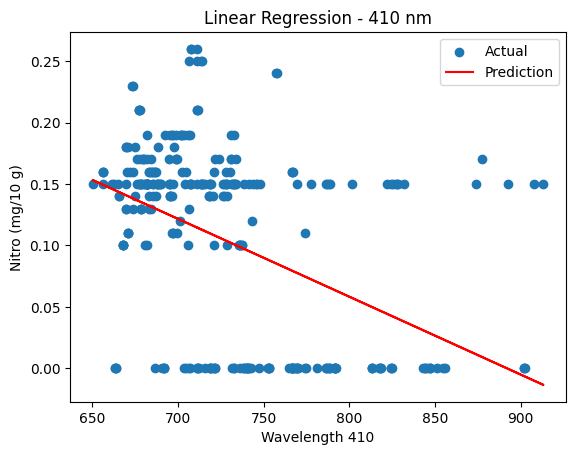

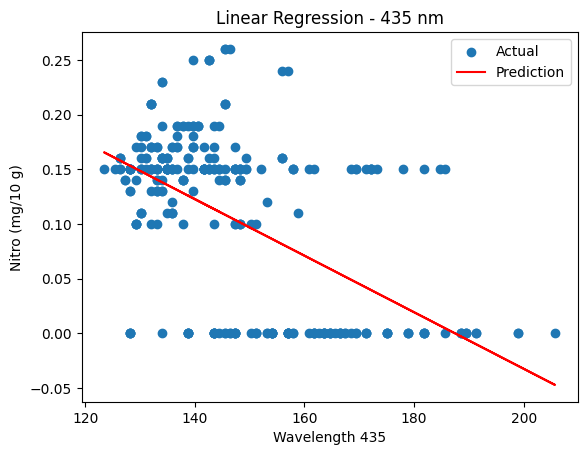

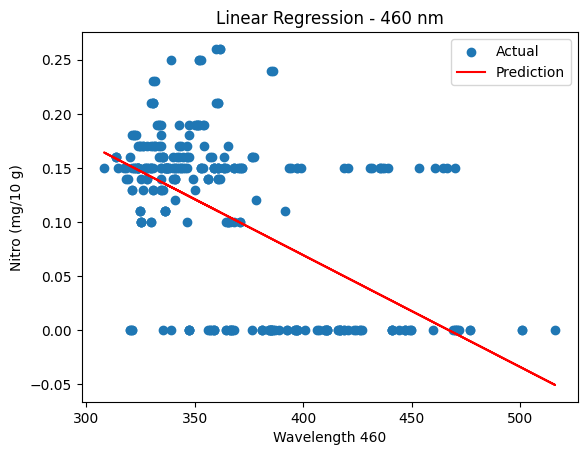

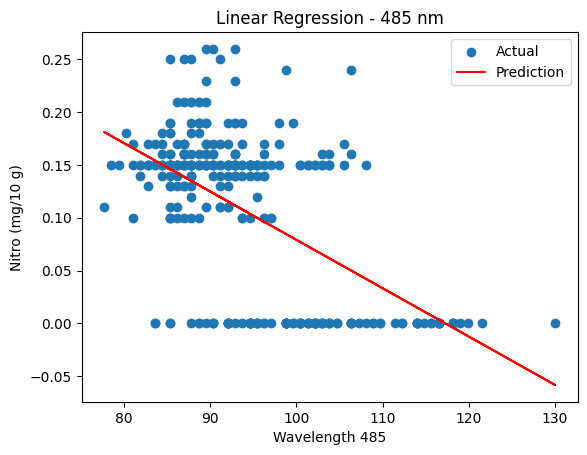

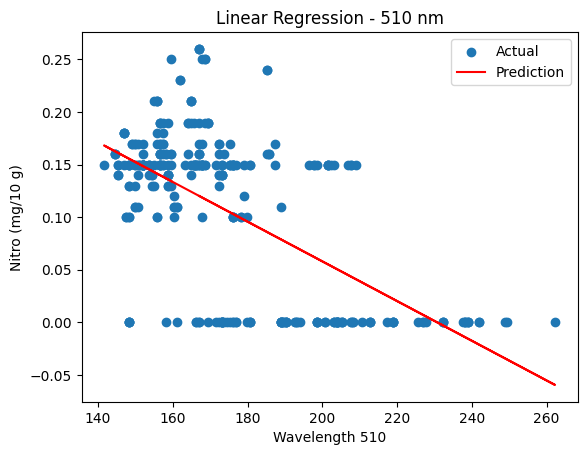

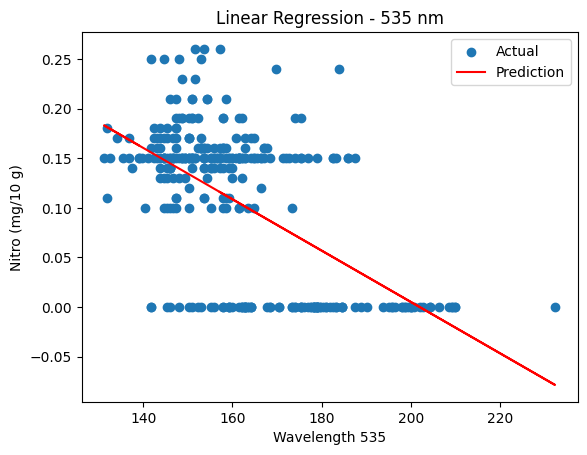

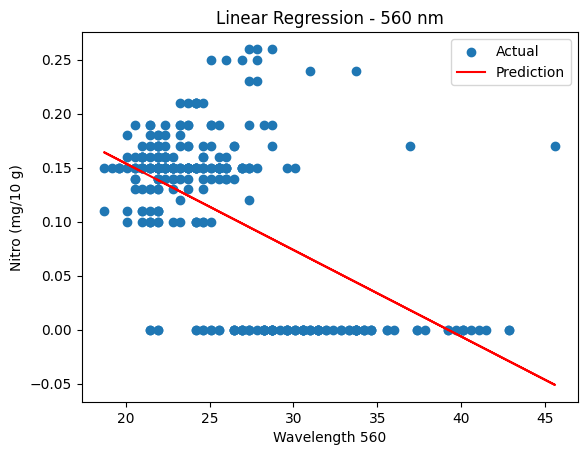

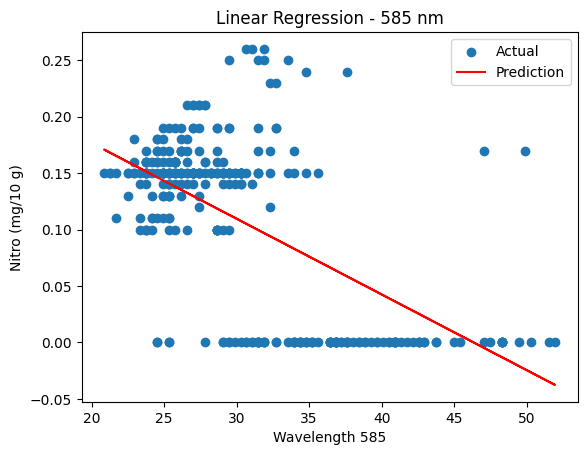

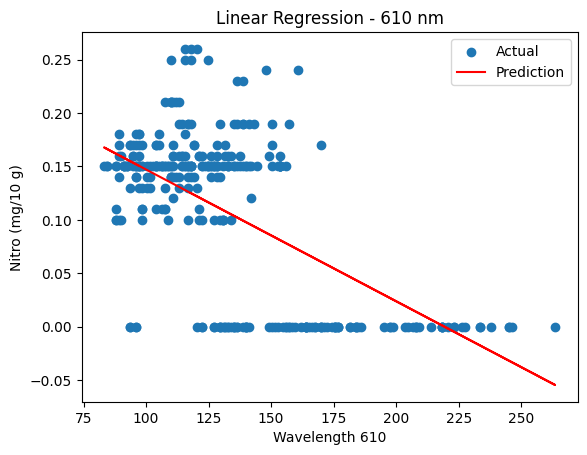

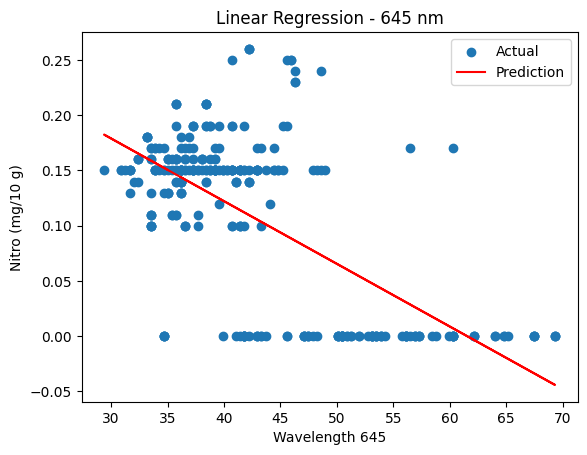

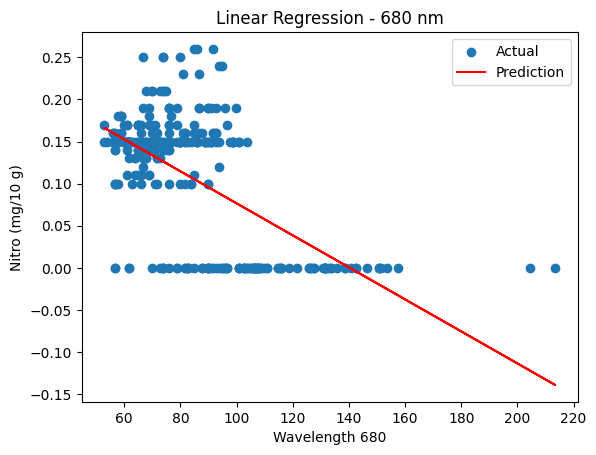

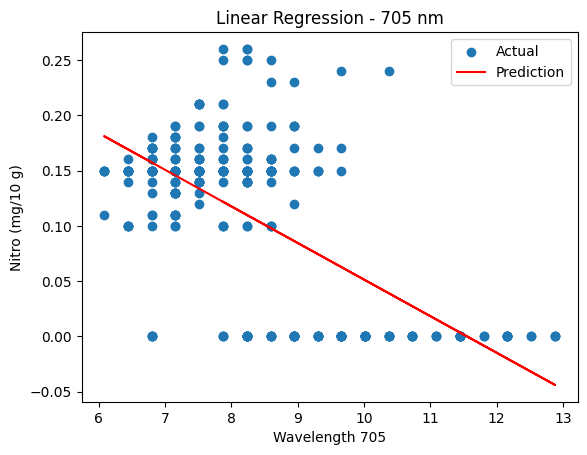

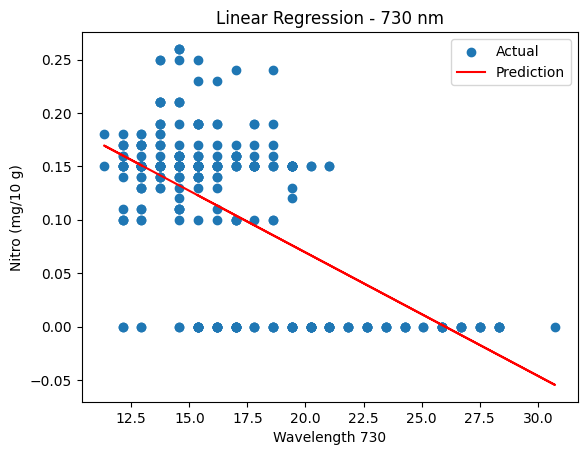

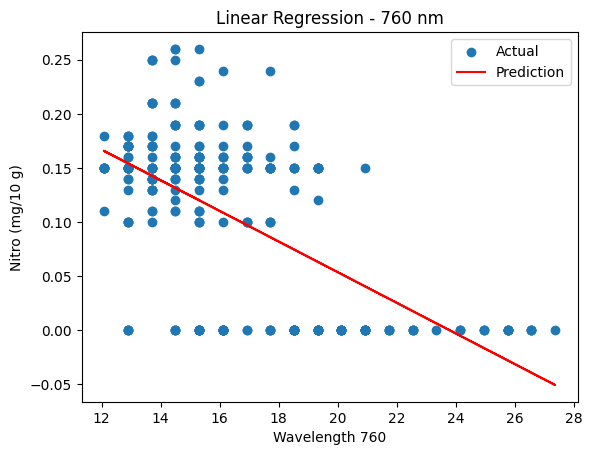

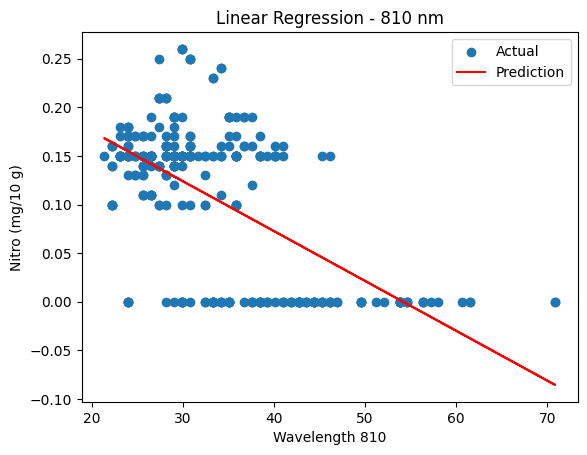

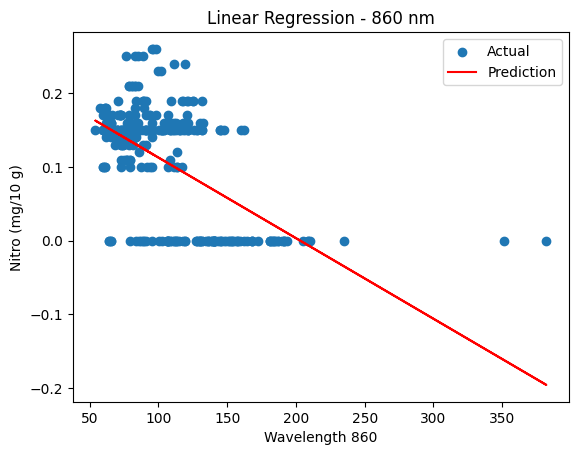

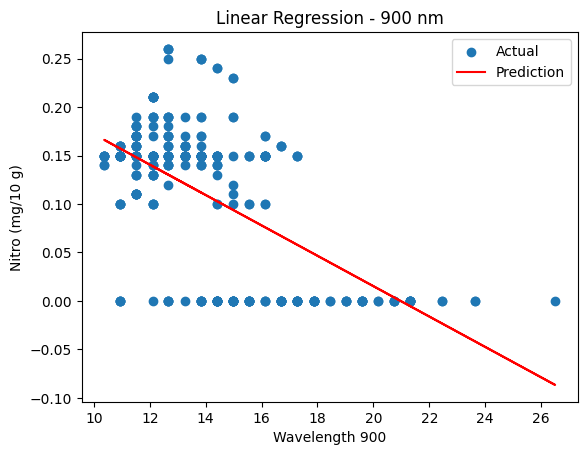

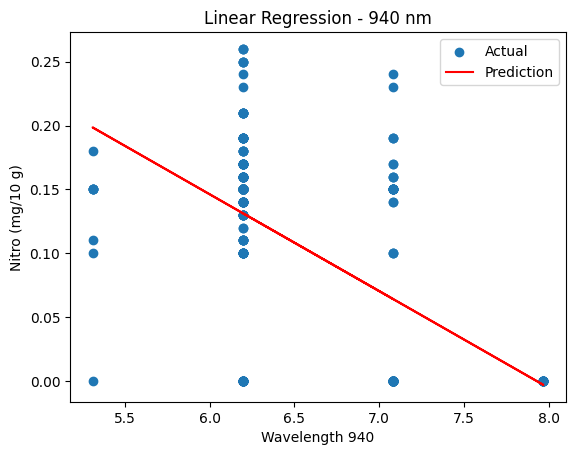

    Wavelength  R2 (Accuracy)       MAE       MSE      RMSE  Precision  \
0          410       0.186930  0.056747  0.004813  0.069375   0.817708   
1          435       0.286519  0.051197  0.004223  0.064988   0.820896   
2          460       0.288536  0.050578  0.004211  0.064896   0.818627   
3          485       0.328524  0.049622  0.003975  0.063046   0.825871   
4          510       0.370108  0.047442  0.003729  0.061062   0.828571   
5          535       0.351676  0.048723  0.003838  0.061949   0.833333   
6          560       0.342000  0.048237  0.003895  0.062410   0.864322   
7          585       0.379452  0.046694  0.003673  0.060608   0.861386   
8          610       0.395799  0.046405  0.003577  0.059804   0.822660   
9          645       0.434632  0.043782  0.003347  0.057850   0.839623   
10         680       0.363223  0.047043  0.003769  0.061395   0.839378   
11         705       0.382059  0.046820  0.003658  0.060480   0.850515   
12         730       0.375294  0.04720

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

# Target column
target = "Nitro (mg/10 g)"

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

results = []

# Loop through each wavelength
for wl in wavelengths:
    # Using df1 instead of df_filtered
    X = df1[[wl]]
    y = df1[target]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Linear Regression
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Regression metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Convert to classification (above/below mean)
    threshold = y.mean()
    y_test_class = (y_test > threshold).astype(int)
    y_pred_class = (y_pred > threshold).astype(int)

    precision = precision_score(y_test_class, y_pred_class, zero_division=0)
    recall = recall_score(y_test_class, y_pred_class, zero_division=0)
    f1 = f1_score(y_test_class, y_pred_class, zero_division=0)

    results.append({
        "Wavelength": wl,
        "R2 (Accuracy)": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Plot graph
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")
    plt.plot(X_test, y_pred, color='red', label="Prediction")
    plt.xlabel(f"Wavelength {wl}")
    plt.ylabel("Nitro (mg/10 g)")
    plt.title(f"Linear Regression - {wl} nm")
    plt.legend()
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

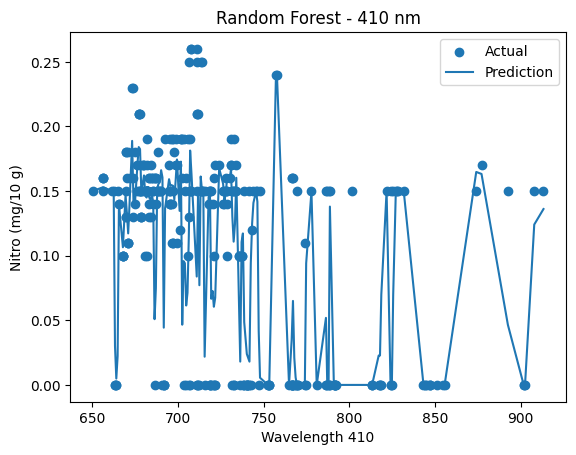

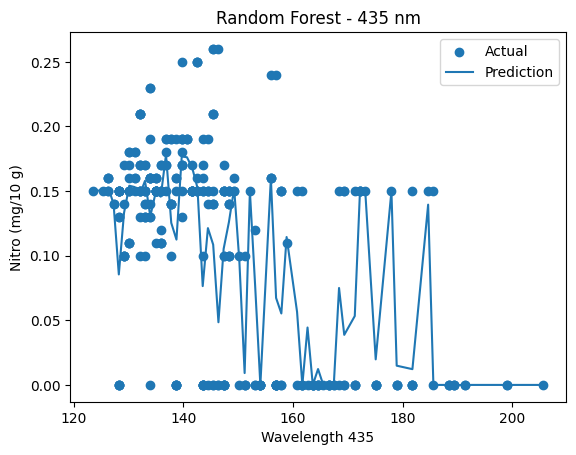

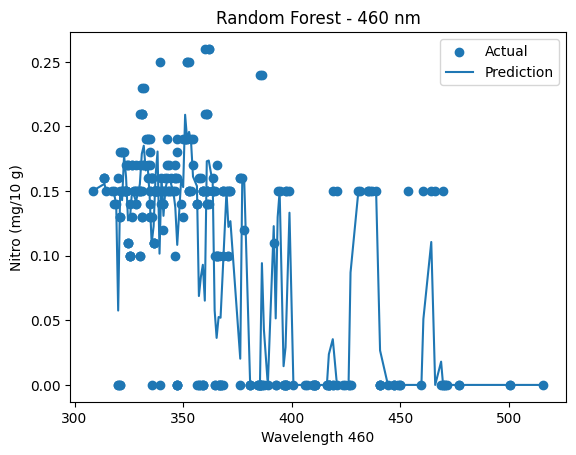

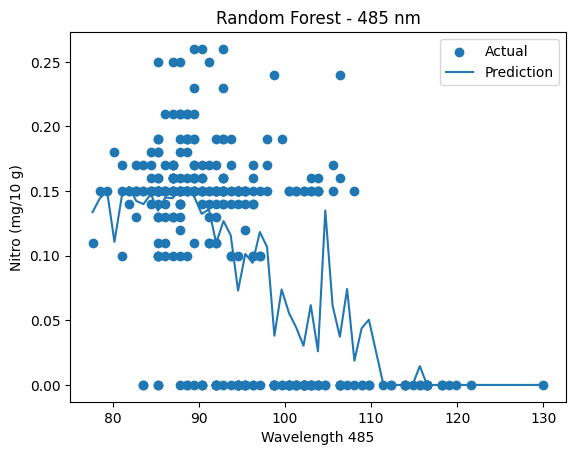

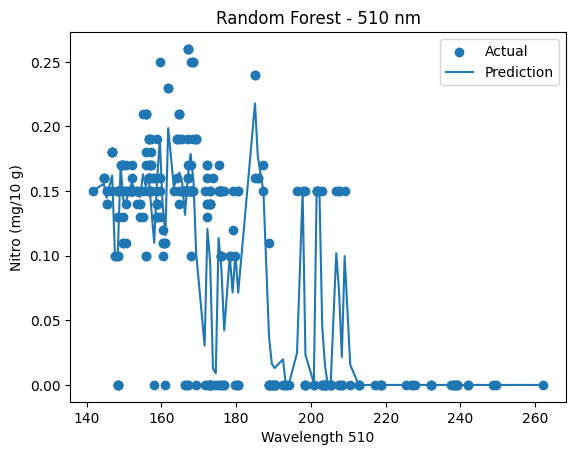

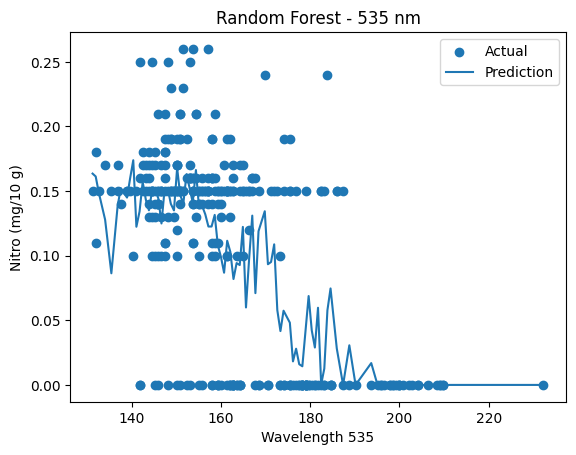

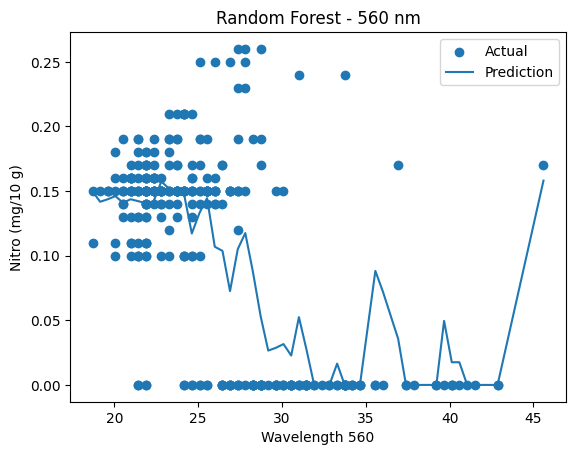

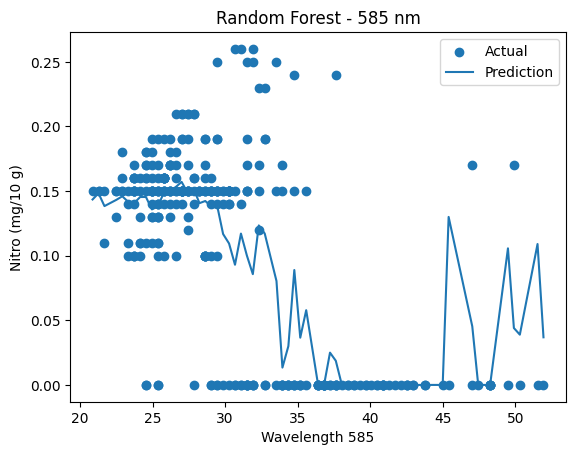

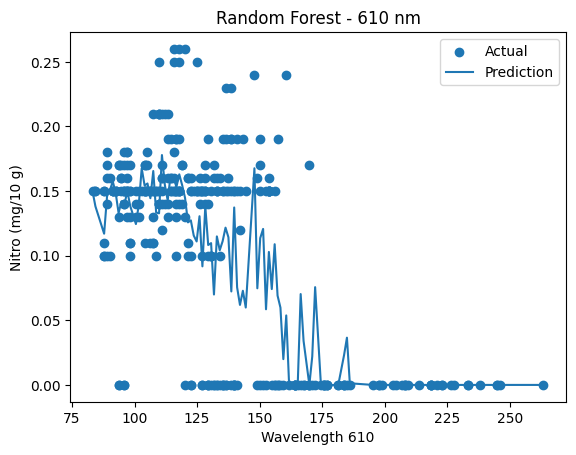

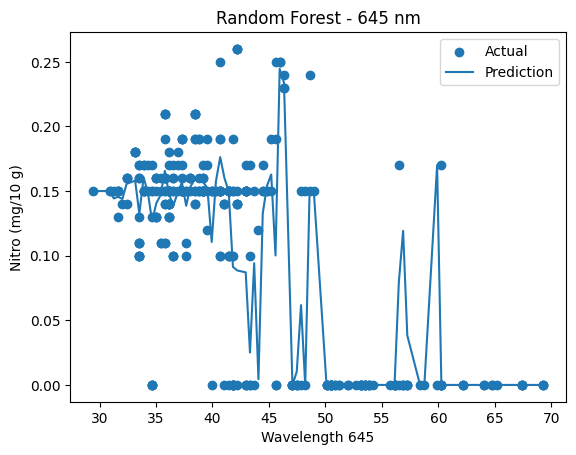

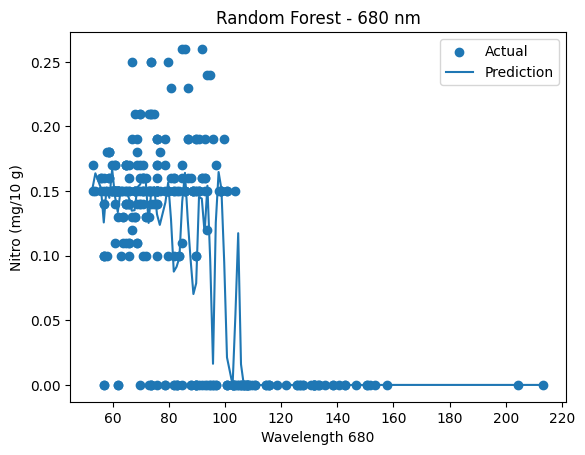

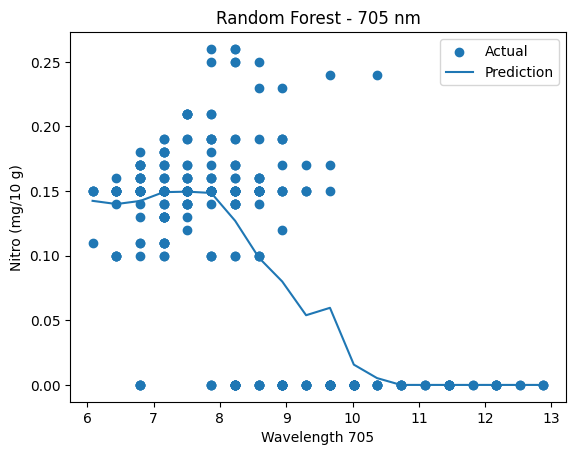

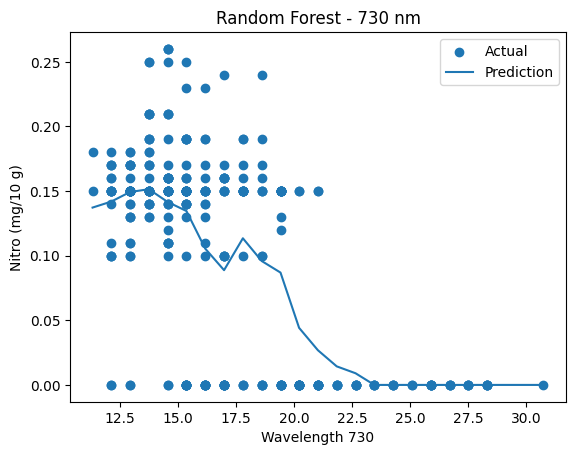

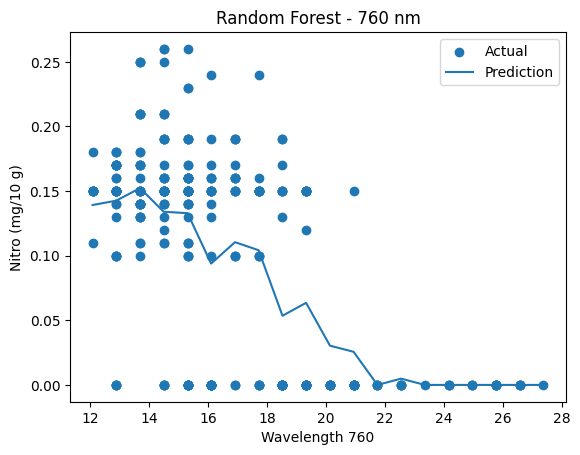

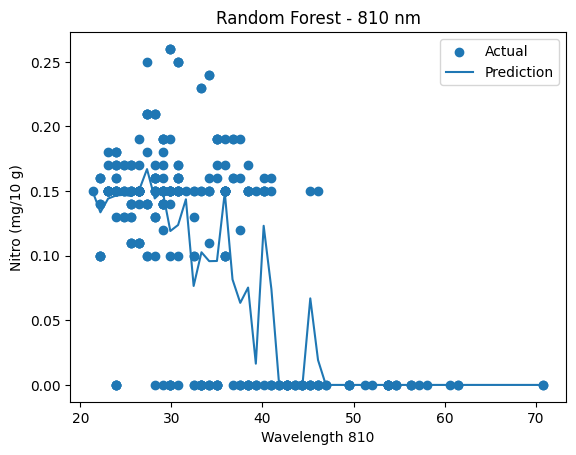

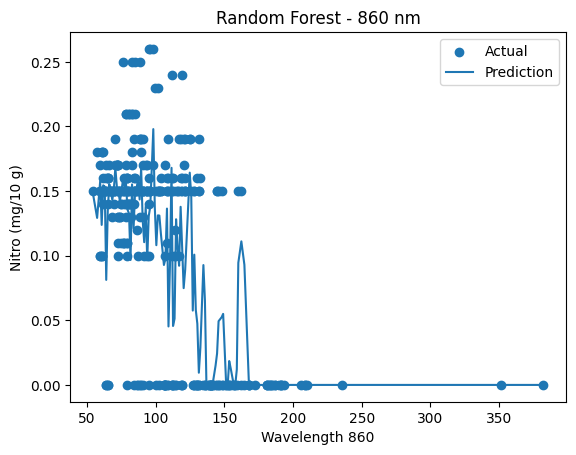

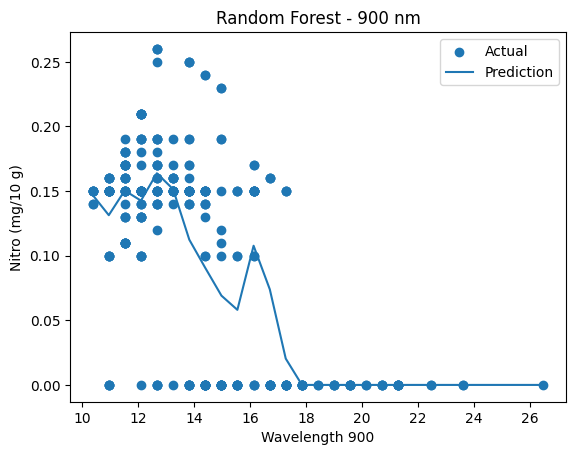

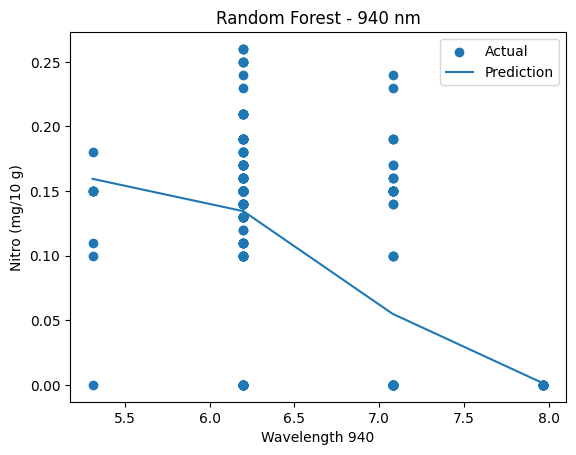

    Wavelength  R2 (Accuracy)       MAE       MSE      RMSE  Precision  \
0          410       0.454424  0.035814  0.003230  0.056829   0.887097   
1          435       0.523326  0.036054  0.002822  0.053119   0.868687   
2          460       0.553006  0.032822  0.002646  0.051439   0.910995   
3          485       0.361147  0.045201  0.003782  0.061495   0.830769   
4          510       0.632330  0.031484  0.002176  0.046652   0.932584   
5          535       0.374261  0.043752  0.003704  0.060861   0.835897   
6          560       0.447024  0.038201  0.003273  0.057213   0.842342   
7          585       0.482420  0.035225  0.003064  0.055352   0.845794   
8          610       0.468484  0.037950  0.003146  0.056092   0.809302   
9          645       0.607953  0.028756  0.002321  0.048174   0.879397   
10         680       0.493685  0.035159  0.002997  0.054746   0.853081   
11         705       0.450656  0.038345  0.003252  0.057025   0.850515   
12         730       0.434788  0.04140

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

# Target column
target = "Nitro (mg/10 g)"

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

results = []

# Loop through each wavelength
for wl in wavelengths:
    # Using df2
    X = df2[[wl]]
    y = df2[target]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 🌲 Random Forest Model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Regression metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Convert to classification (above/below mean)
    threshold = y.mean()
    y_test_class = (y_test > threshold).astype(int)
    y_pred_class = (y_pred > threshold).astype(int)

    precision = precision_score(y_test_class, y_pred_class, zero_division=0)
    recall = recall_score(y_test_class, y_pred_class, zero_division=0)
    f1 = f1_score(y_test_class, y_pred_class, zero_division=0)

    results.append({
        "Wavelength": wl,
        "R2 (Accuracy)": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Plot graph
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")

    # Sort for smoother curve
    sorted_idx = X_test.iloc[:, 0].argsort()
    plt.plot(
        X_test.iloc[sorted_idx],
        y_pred[sorted_idx],
        label="Prediction"
    )

    plt.xlabel(f"Wavelength {wl}")
    plt.ylabel("Nitro (mg/10 g)")
    plt.title(f"Random Forest - {wl} nm")
    plt.legend()
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

# Save results
results_df.to_csv("df2_rf_results.csv", index=False)

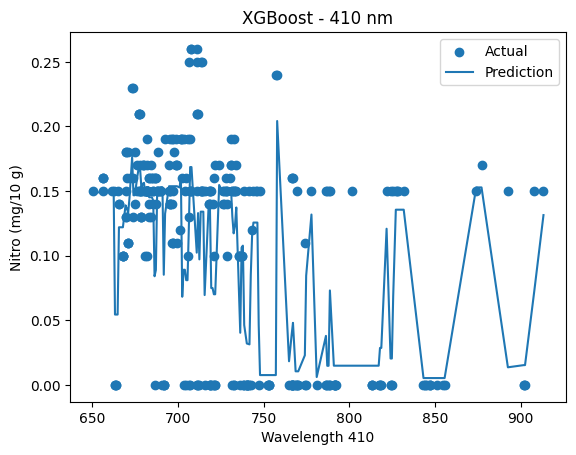

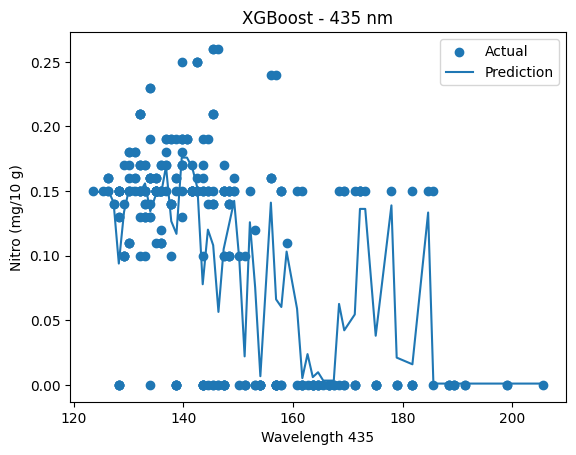

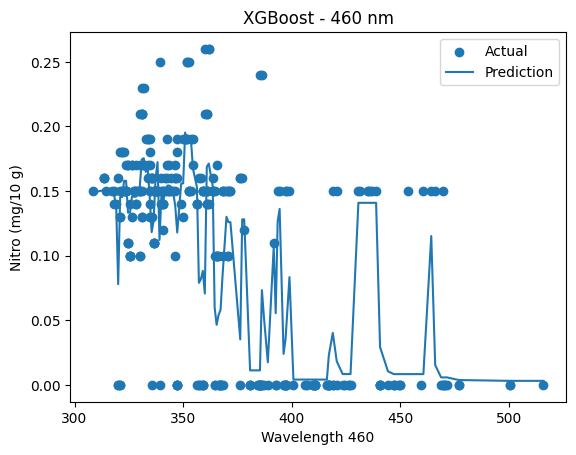

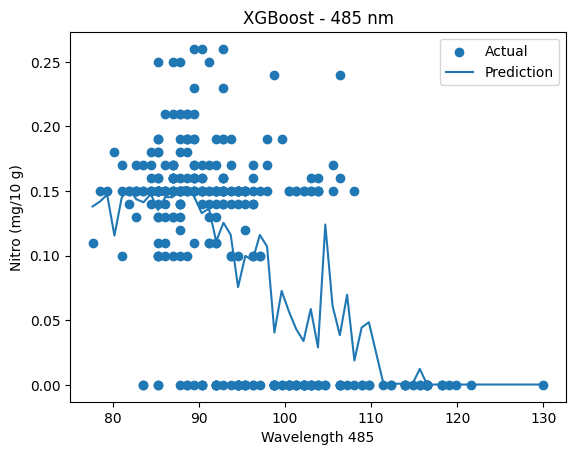

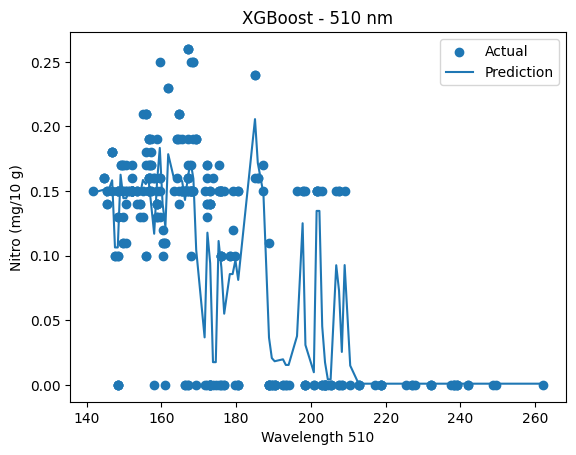

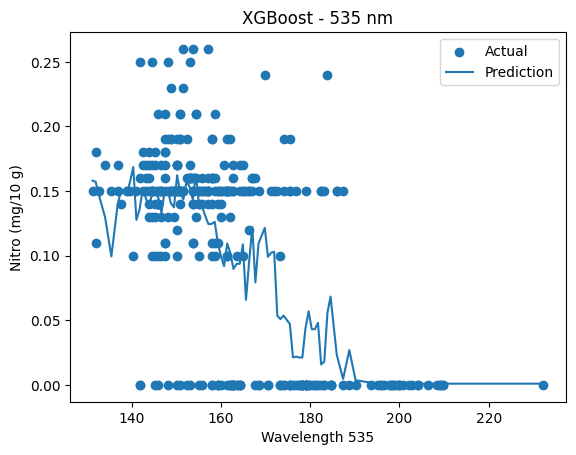

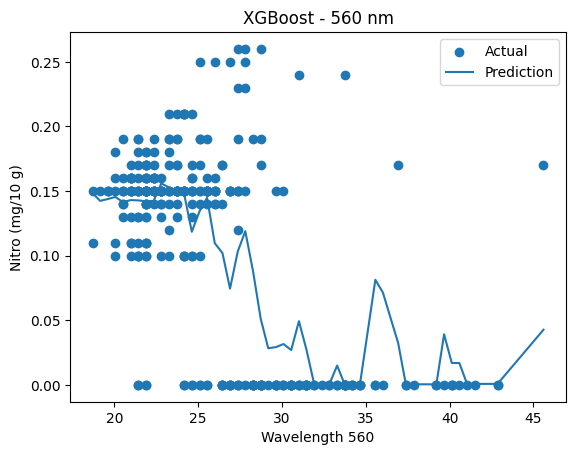

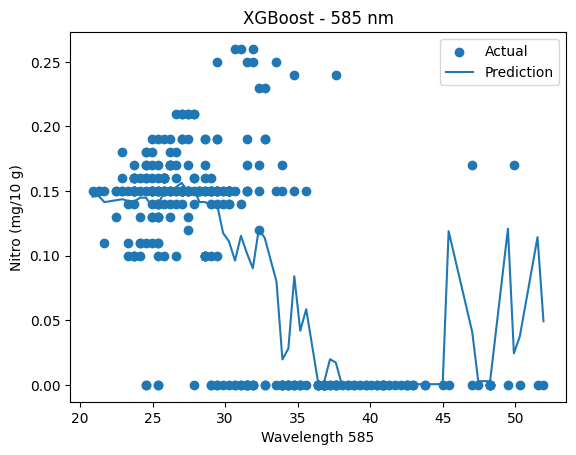

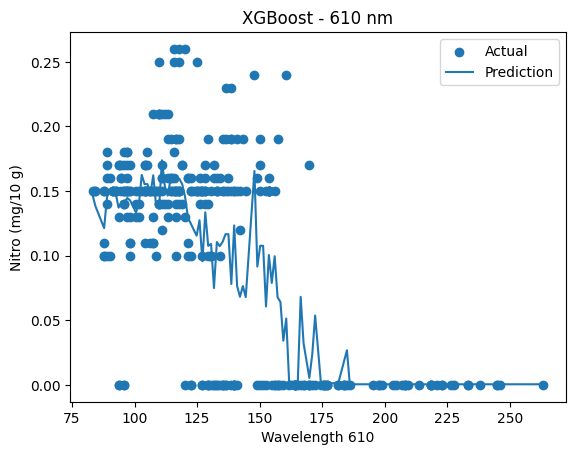

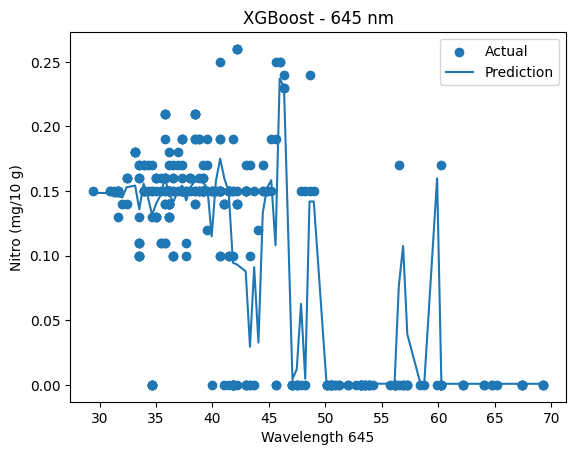

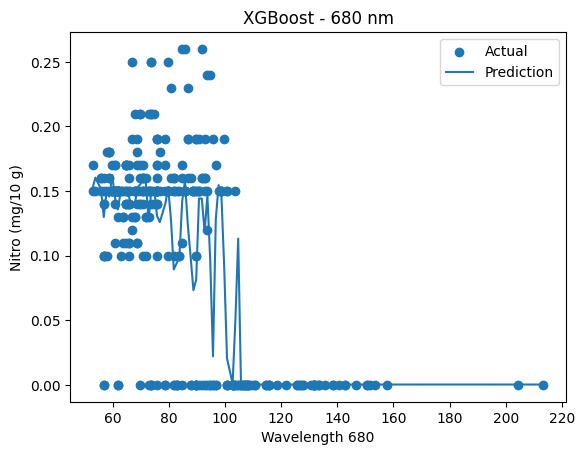

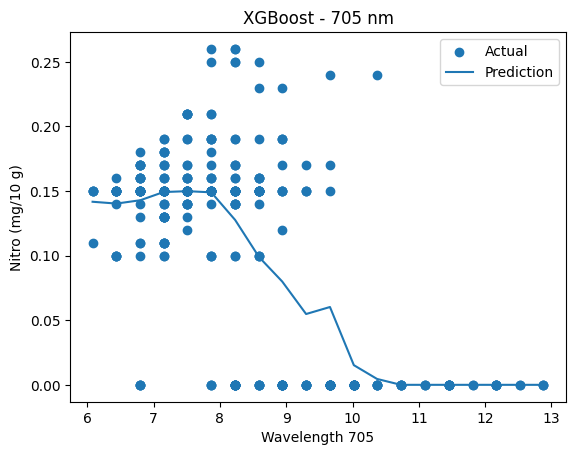

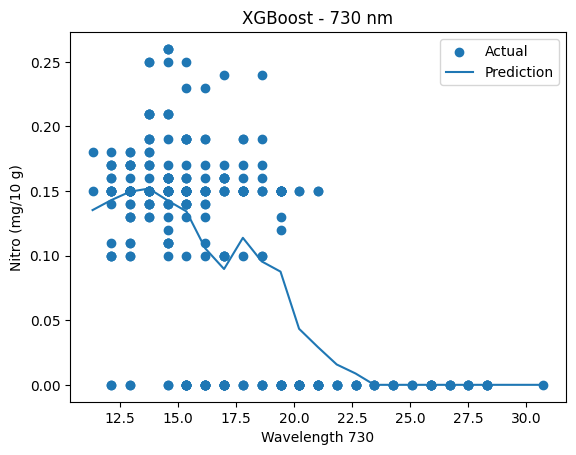

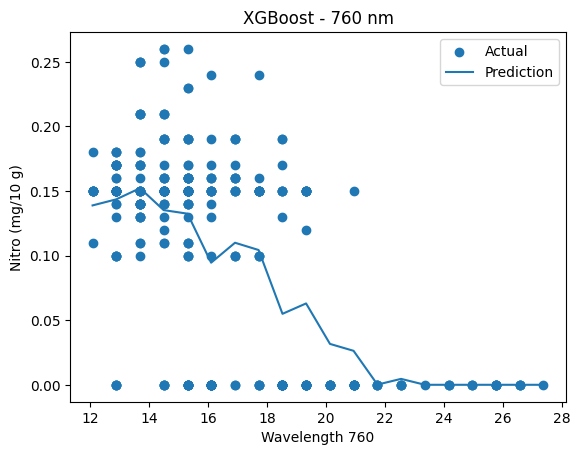

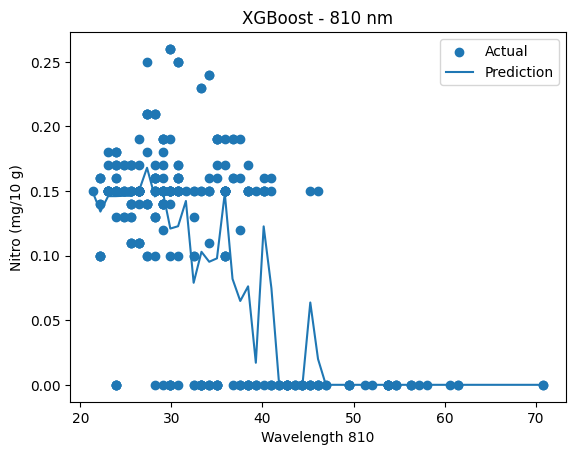

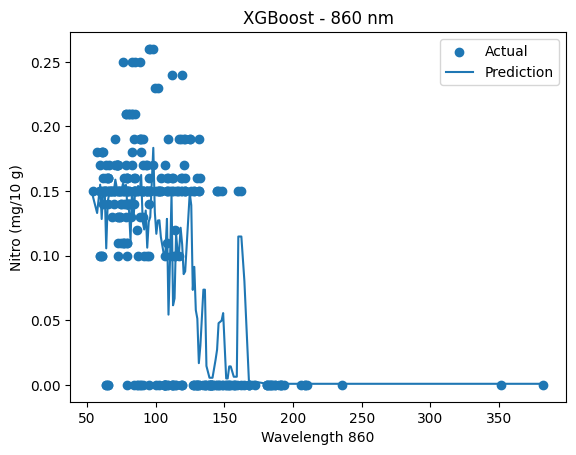

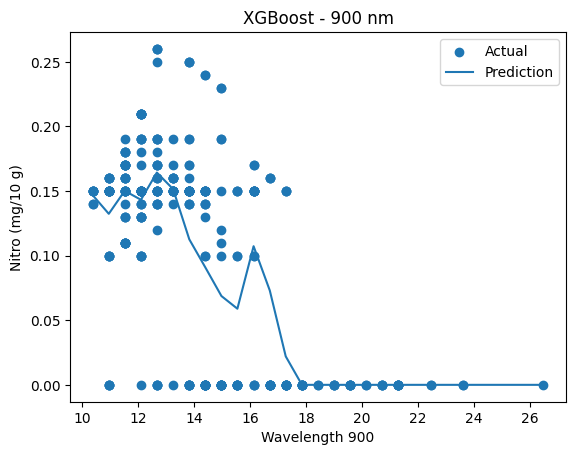

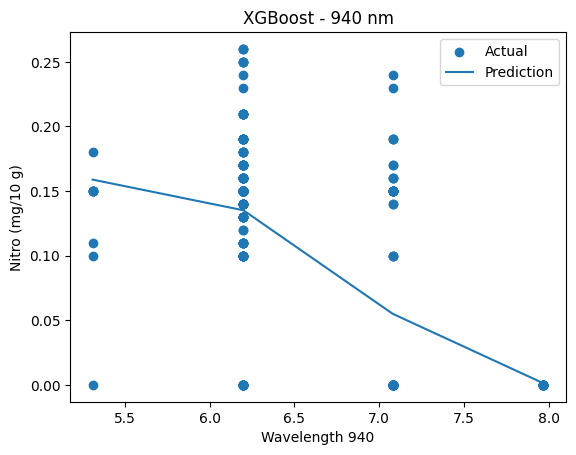

    Wavelength  R2 (Accuracy)       MAE       MSE      RMSE  Precision  \
0          410       0.452730  0.039507  0.003240  0.056917   0.890110   
1          435       0.522976  0.037245  0.002824  0.053139   0.868687   
2          460       0.565043  0.033557  0.002575  0.050742   0.906250   
3          485       0.366430  0.045163  0.003750  0.061240   0.830769   
4          510       0.627425  0.032530  0.002205  0.046962   0.892857   
5          535       0.379889  0.043772  0.003671  0.060586   0.835052   
6          560       0.440939  0.038336  0.003309  0.057527   0.855140   
7          585       0.479236  0.035417  0.003083  0.055521   0.845794   
8          610       0.486031  0.037664  0.003042  0.055158   0.816038   
9          645       0.616686  0.028729  0.002269  0.047634   0.871921   
10         680       0.494617  0.034819  0.002992  0.054695   0.853081   
11         705       0.450607  0.038221  0.003252  0.057027   0.850515   
12         730       0.435642  0.04136

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

# Target column
target = "Nitro (mg/10 g)"

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

results = []

# Loop through each wavelength
for wl in wavelengths:
    # Using df_copies['df3'] to correctly access the DataFrame
    X = df_copies['df3'][[wl]]
    y = df_copies['df3'][target]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ⚡ XGBoost Model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Regression metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Convert to classification (above/below mean)
    threshold = y.mean()
    y_test_class = (y_test > threshold).astype(int)
    y_pred_class = (y_pred > threshold).astype(int)

    precision = precision_score(y_test_class, y_pred_class, zero_division=0)
    recall = recall_score(y_test_class, y_pred_class, zero_division=0)
    f1 = f1_score(y_test_class, y_pred_class, zero_division=0)

    results.append({
        "Wavelength": wl,
        "R2 (Accuracy)": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Plot graph
    plt.figure()
    plt.scatter(X_test, y_test, label="Actual")

    # Sort for smoother curve
    sorted_idx = X_test.iloc[:, 0].argsort()
    plt.plot(
        X_test.iloc[sorted_idx],
        y_pred[sorted_idx],
        label="Prediction"
    )

    plt.xlabel(f"Wavelength {wl}")
    plt.ylabel("Nitro (mg/10 g)")
    plt.title(f"XGBoost - {wl} nm")
    plt.legend()
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
print(results_df)

# Save results
results_df.to_csv("df3_xgb_results.csv", index=False)


Training RandomForest...
RandomForest Best Params: {'max_depth': None, 'n_estimators': 200}
RandomForest R2 Score: 0.9290213603973347

Training XGBoost...
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost R2 Score: 0.9305401038137169

Training GradientBoosting...
GradientBoosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
GradientBoosting R2 Score: 0.9355951854612862

Final Model Comparison:
              Model        R2       MAE      RMSE
0      RandomForest  0.929021  0.009605  0.028165
1           XGBoost  0.930540  0.009569  0.027862
2  GradientBoosting  0.935595  0.009018  0.026829

🏆 Best Model: GradientBoosting

Top Important Wavelengths:
    Wavelength  Importance
9          645    0.637623
0          410    0.074878
10         680    0.065256
2          460    0.044922
16         900    0.043948
4          510    0.030759
1          435    0.023597
8          610    0.023214
14         810    0.016850
6    

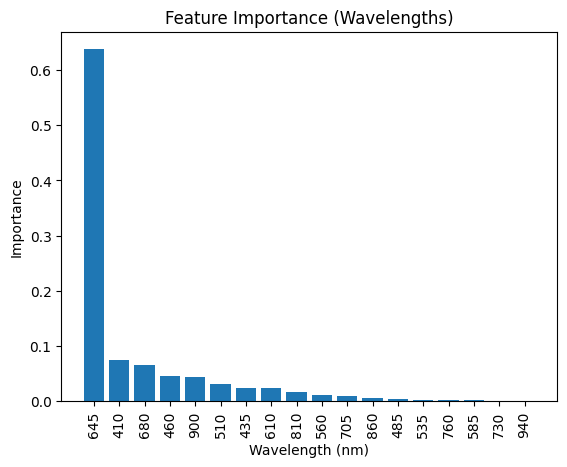


✅ Model saved as posh_nitrogen_model.pkl


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib

# =========================
# 1. DATA PREPARATION
# =========================

df = df_copies['df3'].copy()

# ✅ Updated Target
target = "Posh Nitro (mg/10 g)"

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

X = df[wavelengths]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. MODEL DEFINITIONS
# =========================

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

# =========================
# 3. HYPERPARAMETER TUNING
# =========================

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }
}

best_models = {}
results = []

# =========================
# 4. TRAIN + EVALUATE
# =========================

for name, model in models.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"{name} Best Params:", grid.best_params_)
    print(f"{name} R2 Score:", r2)

# =========================
# 5. RESULTS COMPARISON
# =========================

results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(results_df)

# =========================
# 6. SELECT BEST MODEL
# =========================

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")

# =========================
# 7. FEATURE IMPORTANCE
# =========================

importances = final_model.feature_importances_

feature_df = pd.DataFrame({
    "Wavelength": wavelengths,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Wavelengths:")
print(feature_df.head(10))

# Plot feature importance
plt.figure()
plt.bar(feature_df["Wavelength"].astype(str), feature_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance (Wavelengths)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Importance")
plt.show()

# =========================
# 8. SAVE FINAL MODEL
# =========================

joblib.dump(final_model, "posh_nitrogen_model.pkl")
print("\n✅ Model saved as posh_nitrogen_model.pkl")


Training RandomForest...
RandomForest Best Params: {'max_depth': None, 'n_estimators': 200}
RandomForest R2 Score: 0.9266303365516394

Training XGBoost...
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost R2 Score: 0.9261039557826709

Training GradientBoosting...
GradientBoosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
GradientBoosting R2 Score: 0.9267823919579059

Final Model Comparison:
              Model        R2       MAE      RMSE
0      RandomForest  0.926630  0.024143  0.072592
1           XGBoost  0.926104  0.023889  0.072852
2  GradientBoosting  0.926782  0.025133  0.072517

🏆 Best Model: GradientBoosting

Top Important Wavelengths:
    Wavelength  Importance
9          645    0.635579
10         680    0.066493
0          410    0.065944
2          460    0.043999
16         900    0.043392
4          510    0.033660
1          435    0.026511
8          610    0.021627
6          560    0.016102
14   

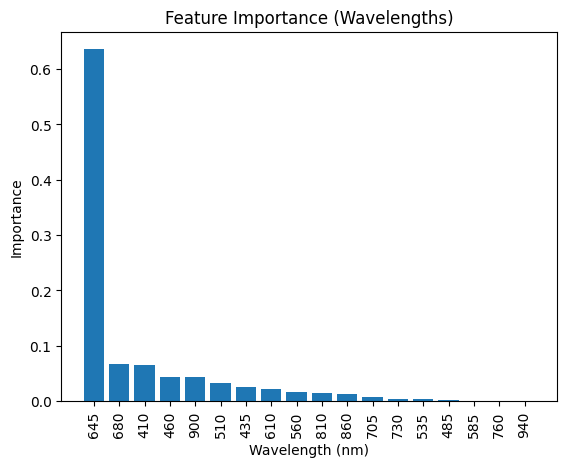


✅ Model saved as pota_nitrogen_model.pkl


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib

# =========================
# 1. DATA PREPARATION
# =========================

df = df_copies['df3'].copy()

# ✅ Updated Target
target = "Pota Nitro (mg/10 g)"

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

X = df[wavelengths]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. MODEL DEFINITIONS
# =========================

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

# =========================
# 3. HYPERPARAMETER TUNING
# =========================

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }
}

best_models = {}
results = []

# =========================
# 4. TRAIN + EVALUATE
# =========================

for name, model in models.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"{name} Best Params:", grid.best_params_)
    print(f"{name} R2 Score:", r2)

# =========================
# 5. RESULTS COMPARISON
# =========================

results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(results_df)

# =========================
# 6. SELECT BEST MODEL
# =========================

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")

# =========================
# 7. FEATURE IMPORTANCE
# =========================

importances = final_model.feature_importances_

feature_df = pd.DataFrame({
    "Wavelength": wavelengths,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Wavelengths:")
print(feature_df.head(10))

# Plot feature importance
plt.figure()
plt.bar(feature_df["Wavelength"].astype(str), feature_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance (Wavelengths)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Importance")
plt.show()

# =========================
# 8. SAVE FINAL MODEL
# =========================

joblib.dump(final_model, "pota_nitrogen_model.pkl")
print("\n✅ Model saved as pota_nitrogen_model.pkl")


Training RandomForest...
RandomForest Best Params: {'max_depth': None, 'n_estimators': 200}
RandomForest R2 Score: 0.6439799170182954

Training XGBoost...
XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
XGBoost R2 Score: 0.6121213605878538

Training GradientBoosting...
GradientBoosting Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
GradientBoosting R2 Score: 0.6010079498122253

Final Model Comparison:
              Model        R2       MAE      RMSE
0      RandomForest  0.643980  0.166172  0.233874
1           XGBoost  0.612121  0.174754  0.244114
2  GradientBoosting  0.601008  0.178470  0.247586

🏆 Best Model: RandomForest

Top Important Wavelengths:
    Wavelength  Importance
9          645    0.137484
0          410    0.119593
2          460    0.110124
1          435    0.101286
4          510    0.082671
15         860    0.051732
10         680    0.050474
5          535    0.048643
7          585    0.047218
8        

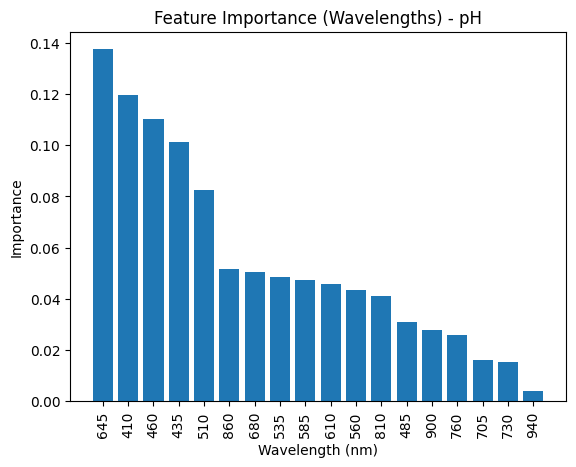


✅ Model saved as ph_model.pkl


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import joblib

# =========================
# 1. DATA PREPARATION
# =========================

df = df_copies['df3'].copy()

# ✅ Updated Target
target = "Ph"   # ⚠️ verify column name (Ph / pH / Ph )

# Wavelength columns
wavelengths = [410,435,460,485,510,535,560,585,610,645,
               680,705,730,760,810,860,900,940]

X = df[wavelengths]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. MODEL DEFINITIONS
# =========================

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

# =========================
# 3. HYPERPARAMETER TUNING
# =========================

param_grids = {
    "RandomForest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }
}

best_models = {}
results = []

# =========================
# 4. TRAIN + EVALUATE
# =========================

for name, model in models.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"{name} Best Params:", grid.best_params_)
    print(f"{name} R2 Score:", r2)

# =========================
# 5. RESULTS COMPARISON
# =========================

results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:")
print(results_df)

# =========================
# 6. SELECT BEST MODEL
# =========================

best_model_name = results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
final_model = best_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")

# =========================
# 7. FEATURE IMPORTANCE
# =========================

importances = final_model.feature_importances_

feature_df = pd.DataFrame({
    "Wavelength": wavelengths,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Wavelengths:")
print(feature_df.head(10))

# Plot feature importance
plt.figure()
plt.bar(feature_df["Wavelength"].astype(str), feature_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance (Wavelengths) - pH")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Importance")
plt.show()

# =========================
# 8. SAVE FINAL MODEL
# =========================

joblib.dump(final_model, "ph_model.pkl")
print("\n✅ Model saved as ph_model.pkl")